# 🌾 EDA — Irrigation Need Prediction
**Task:** Multiclass Classification (Low / Medium / High)  
**Metric:** Balanced Accuracy  
**Dataset:** 630,000 rows × 21 columns · No missing values

---
| Section | Nội dung |
|---------|---------|
| 1 | Setup & Load |
| 2 | Overview & Thống kê mô tả |
| 3 | Target Distribution |
| 4 | Numeric Features — Distribution & Outliers |
| 5 | Categorical Features — Cardinality & Frequency |
| 6 | Correlation & Relationships |
| 7 | Feature vs Target (numeric) |
| 8 | Feature vs Target (categorical) |
| 9 | Key Insights |


## 1. Setup & Load

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

TRAIN_PATH = "../data/raw/train.csv"
TARGET     = "Irrigation_Need"
TARGET_ORDER = ["Low", "Medium", "High"]
PALETTE    = {"Low": "#4ade80", "Medium": "#fb923c", "High": "#f87171"}

NUM_COLS = ['Soil_pH','Soil_Moisture','Organic_Carbon','Electrical_Conductivity',
            'Temperature_C','Humidity','Rainfall_mm','Sunlight_Hours',
            'Wind_Speed_kmh','Field_Area_hectare','Previous_Irrigation_mm']
CAT_COLS = ['Soil_Type','Crop_Type','Crop_Growth_Stage','Season',
            'Irrigation_Type','Water_Source','Mulching_Used','Region']

df = pd.read_csv(TRAIN_PATH)
df[TARGET] = pd.Categorical(df[TARGET], categories=TARGET_ORDER, ordered=True)

print(f"Shape  : {df.shape}")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)


Shape  : (630000, 21)
Memory : 336.6 MB


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.9200,32.5800,1.0100,3.0500,15.0100,50.6100,725.9900,5.9000,16.7900,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.8200,No,112.1600,East,Low
1,1,Clay,7.0800,56.6100,0.4400,2.0000,22.9200,67.8600,985.6600,6.9800,3.3900,Wheat,Vegetative,Kharif,Rainfed,River,5.2700,Yes,47.1600,South,Low
2,2,Clay,5.6900,27.7100,0.8100,2.8300,26.9700,92.2200,2201.7000,6.0500,3.8500,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.2400,Yes,110.3800,North,Low


## 2. Overview & Thống kê mô tả

In [2]:
# ── Dtypes + missing ─────────────────────────────────────────────────────────
info = pd.DataFrame({
    "dtype":   df.dtypes,
    "missing": df.isnull().sum(),
    "missing%": df.isnull().mean().mul(100).round(2),
    "nunique": df.nunique(),
    "sample":  [df[c].dropna().iloc[0] if len(df[c].dropna()) else None for c in df.columns],
})
info


,dtype,missing,missing%,nunique,sample
id,int64,0,0.0000,630000,0
Soil_Type,object,0,0.0000,4,Loamy
Soil_pH,float64,0,0.0000,341,4.9200
Soil_Moisture,float64,0,0.0000,5223,32.5800
Organic_Carbon,float64,0,0.0000,131,1.0100
Electrical_Conductivity,float64,0,0.0000,341,3.0500
Temperature_C,float64,0,0.0000,2934,15.0100
Humidity,float64,0,0.0000,6475,50.6100
Rainfall_mm,float64,0,0.0000,19308,725.9900
Sunlight_Hours,float64,0,0.0000,701,5.9000


In [3]:
# ── Numeric descriptive stats ────────────────────────────────────────────────
df[NUM_COLS].describe().T.style.background_gradient(cmap="Blues", subset=["mean","std"])


,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.000000,6.482497,0.922504,4.800000,5.690000,6.440000,7.270000,8.200000
Soil_Moisture,630000.000000,37.304482,16.377082,8.000000,23.340000,37.750000,51.270000,64.990000
Organic_Carbon,630000.000000,0.922858,0.365808,0.300000,0.610000,0.910000,1.220000,1.600000
Electrical_Conductivity,630000.000000,1.744605,0.952321,0.100000,0.930000,1.740000,2.580000,3.500000
Temperature_C,630000.000000,26.998166,8.623621,12.000000,19.517500,26.960000,34.540000,42.000000
Humidity,630000.000000,61.563180,19.708152,25.000000,45.390000,61.650000,79.120000,94.990000
Rainfall_mm,630000.000000,1462.207566,612.989738,0.380000,954.570000,1467.160000,2054.280000,2499.690000
Sunlight_Hours,630000.000000,7.513382,1.999322,4.000000,5.760000,7.580000,9.250000,11.000000
Wind_Speed_kmh,630000.000000,10.375394,5.689458,0.500000,5.280000,10.480000,15.430000,20.000000
Field_Area_hectare,630000.000000,7.517745,4.218124,0.300000,3.880000,7.380000,11.140000,15.000000


In [4]:
# ── Skewness & Kurtosis ──────────────────────────────────────────────────────
skew_kurt = pd.DataFrame({
    "skewness": df[NUM_COLS].skew().round(3),
    "kurtosis": df[NUM_COLS].kurt().round(3),
})
skew_kurt["skew_flag"] = skew_kurt["skewness"].abs().apply(
    lambda x: "⚠️ high" if x > 1 else ("mild" if x > 0.5 else "✅ ok")
)
skew_kurt.sort_values("skewness", ascending=False)


,skewness,kurtosis,skew_flag
Organic_Carbon,0.1050,-1.1660,✅ ok
Soil_pH,0.0700,-1.1450,✅ ok
Field_Area_hectare,0.0520,-1.1760,✅ ok
Electrical_Conductivity,0.0480,-1.1480,✅ ok
Temperature_C,-0.0040,-1.2060,✅ ok
Previous_Irrigation_mm,-0.0170,-1.2550,✅ ok
Wind_Speed_kmh,-0.0280,-1.2420,✅ ok
Sunlight_Hours,-0.0350,-1.2060,✅ ok
Soil_Moisture,-0.0640,-1.1810,✅ ok
Humidity,-0.0890,-1.1640,✅ ok


## 3. Target Distribution
> ⚠️ **Class imbalance rõ ràng:** High chỉ chiếm ~3.3% — đây là lý do dùng **Balanced Accuracy**.


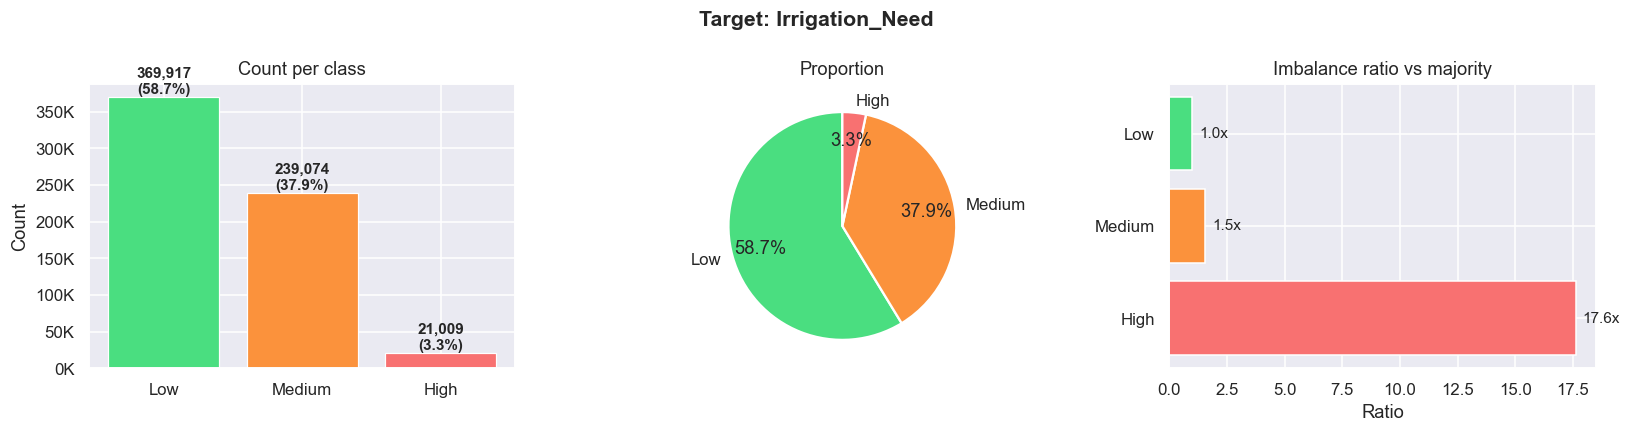


Imbalance ratio (Low:High) = 17.6x
→ Balanced Accuracy là metric phù hợp để penalize việc bỏ qua class High


In [5]:
vc = df[TARGET].value_counts()[TARGET_ORDER]
pct = vc / len(df) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Count bar
bars = axes[0].bar(vc.index, vc.values,
                   color=[PALETTE[c] for c in vc.index], edgecolor="white", linewidth=0.8)
for bar, v, p in zip(bars, vc.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f"{v:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Count per class", fontsize=12)
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}K"))

# Pie
axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=[PALETTE[c] for c in vc.index],
            startangle=90, pctdistance=0.75,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Proportion", fontsize=12)

# Imbalance ratio
ratios = vc.max() / vc
axes[2].barh(ratios.index[::-1], ratios.values[::-1],
             color=[PALETTE[c] for c in ratios.index[::-1]], edgecolor="white")
for i, (idx, v) in enumerate(ratios[::-1].items()):
    axes[2].text(v + 0.3, i, f"{v:.1f}x", va="center", fontsize=10)
axes[2].set_title("Imbalance ratio vs majority", fontsize=12)
axes[2].set_xlabel("Ratio")

plt.suptitle("Target: Irrigation_Need", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (Low:High) = {vc['Low']/vc['High']:.1f}x")
print("→ Balanced Accuracy là metric phù hợp để penalize việc bỏ qua class High")


## 4. Numeric Features — Distribution & Outliers

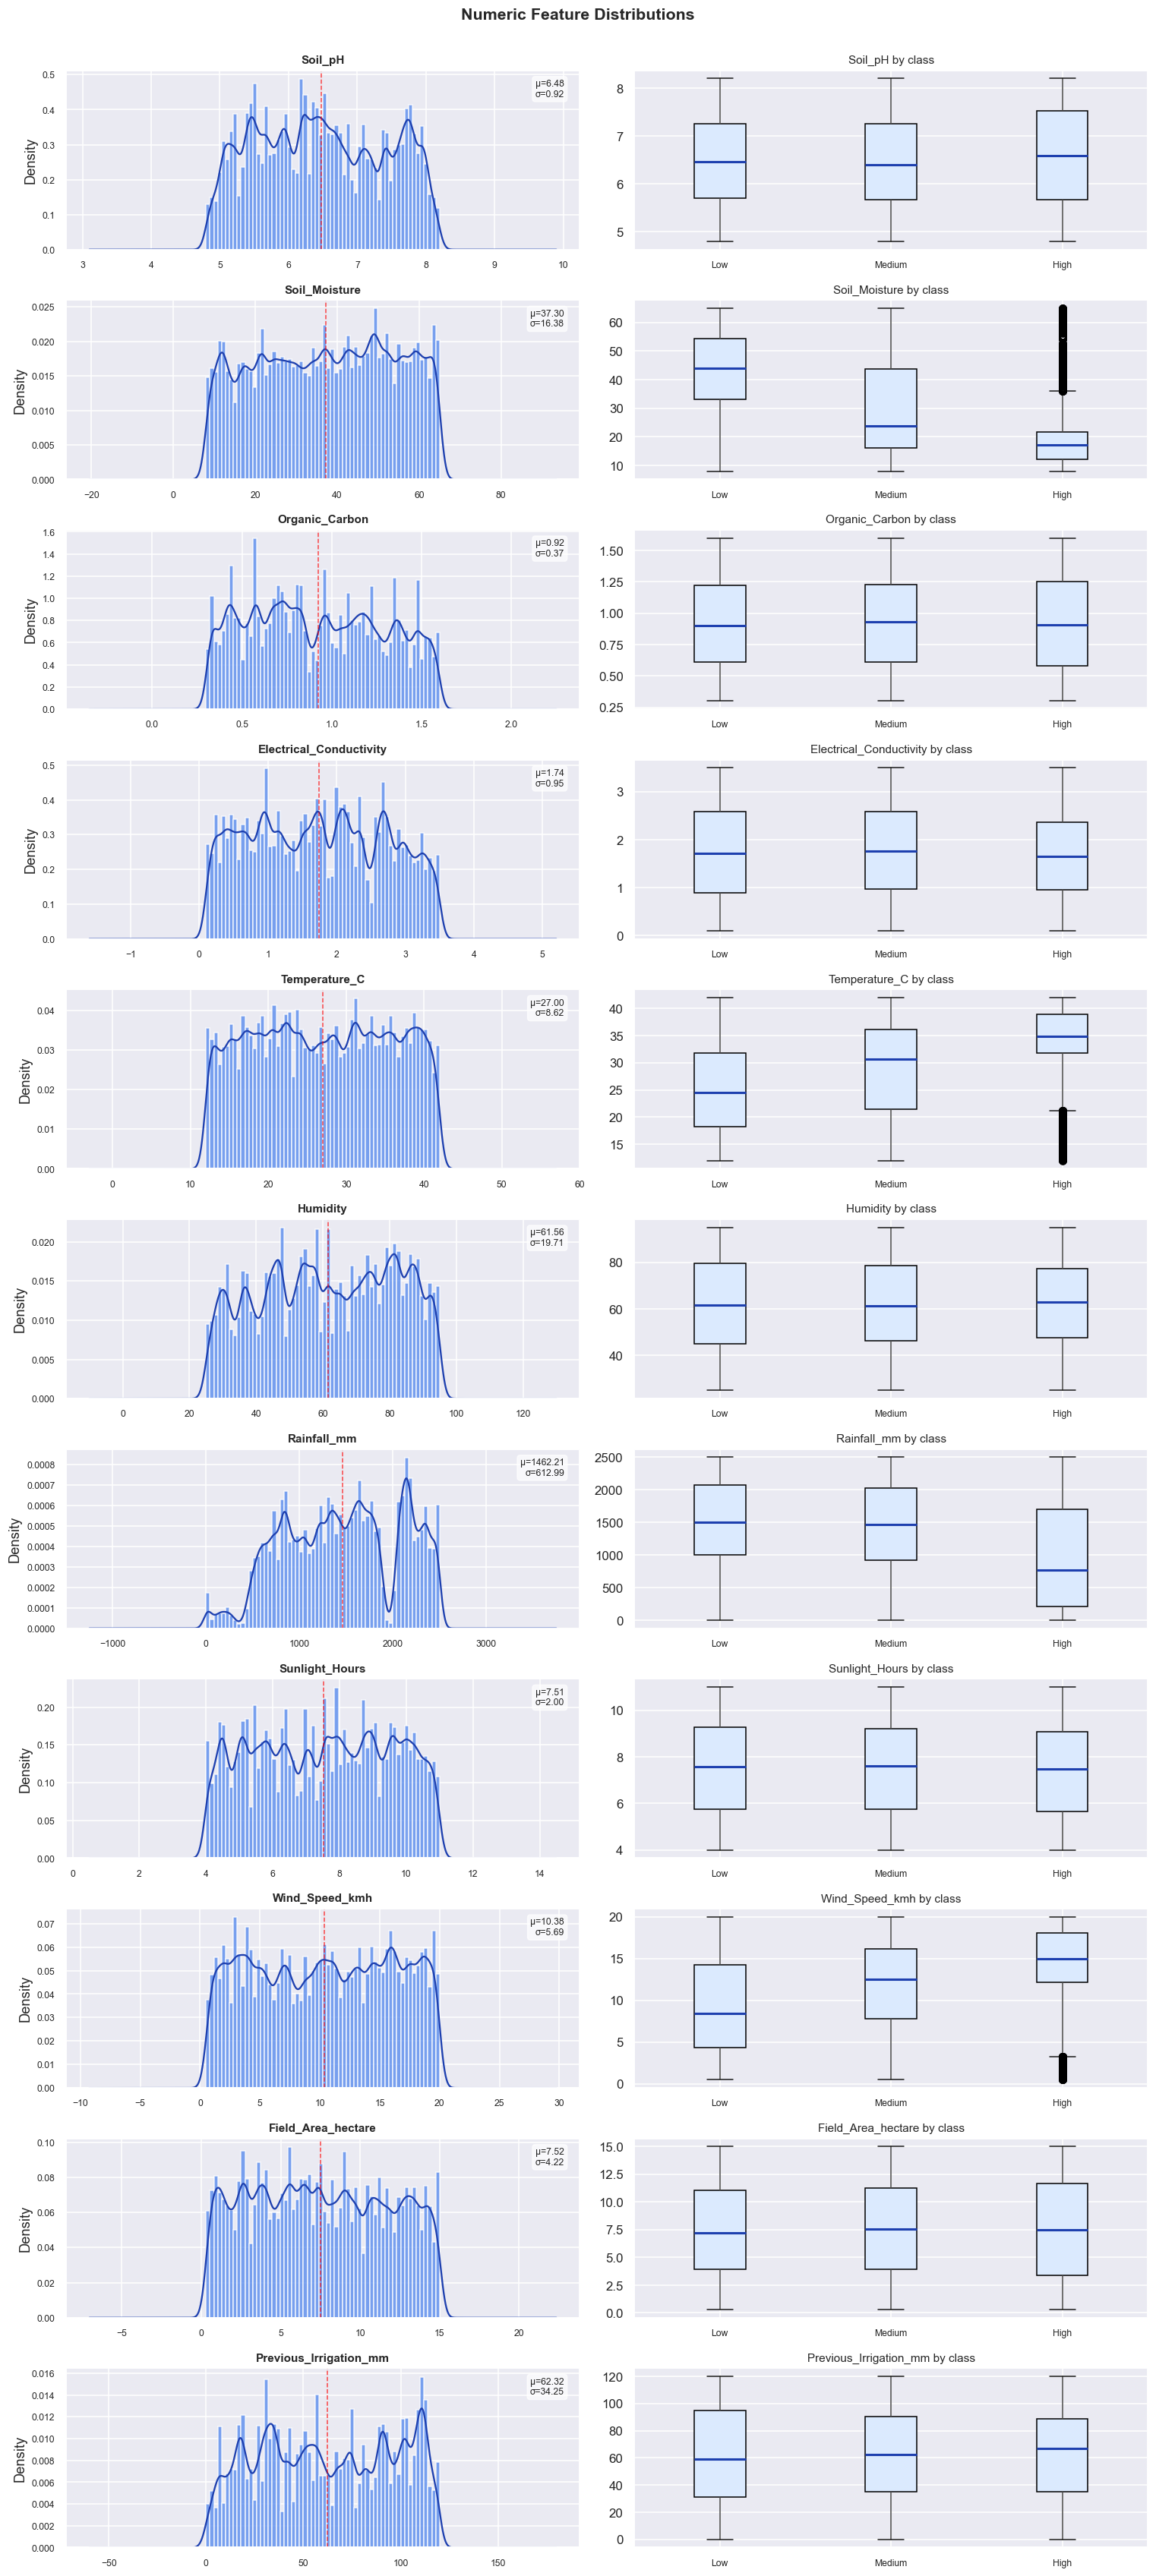

In [6]:
# ── Distribution + boxplot cho từng numeric feature ──────────────────────────
fig, axes = plt.subplots(len(NUM_COLS), 2, figsize=(14, len(NUM_COLS) * 2.8))

for i, col in enumerate(NUM_COLS):
    data = df[col]

    # Histogram + KDE
    axes[i,0].hist(data, bins=60, color="#5b8dee", edgecolor="white",
                   alpha=0.8, density=True)
    data.plot.kde(ax=axes[i,0], color="#1e40af", linewidth=1.5)
    axes[i,0].set_title(col, fontsize=10, fontweight="bold")
    axes[i,0].set_ylabel("Density")
    axes[i,0].tick_params(labelsize=8)

    # Stat annotations
    mu, sd = data.mean(), data.std()
    axes[i,0].axvline(mu, color="red", linestyle="--", linewidth=1, alpha=0.7)
    axes[i,0].text(0.97, 0.95, f"μ={mu:.2f}\nσ={sd:.2f}",
                   transform=axes[i,0].transAxes, ha="right", va="top",
                   fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    # Boxplot by target
    df.boxplot(column=col, by=TARGET, ax=axes[i,1],
               positions=range(len(TARGET_ORDER)),
               patch_artist=True,
               boxprops=dict(facecolor="#dbeafe"),
               medianprops=dict(color="#1e40af", linewidth=2))
    axes[i,1].set_xticklabels(TARGET_ORDER, fontsize=8)
    axes[i,1].set_title(f"{col} by Target", fontsize=10, fontweight="bold")
    axes[i,1].set_xlabel("")
    plt.sca(axes[i,1]); plt.title(f"{col} by class", fontsize=10)

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold", y=1.001)
plt.tight_layout()
plt.show()


In [7]:
# ── Outlier detection (IQR method) ───────────────────────────────────────────
outlier_summary = []
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({
        "feature": col, "Q1": round(Q1,3), "Q3": round(Q3,3),
        "IQR": round(IQR,3),
        "n_outliers": n_out,
        "outlier_%": round(n_out/len(df)*100, 2),
    })

out_df = pd.DataFrame(outlier_summary).set_index("feature")
out_df.style.background_gradient(cmap="YlOrRd", subset=["outlier_%"])


,Q1,Q3,IQR,n_outliers,outlier_%
feature,,,,,
Soil_pH,5.690000,7.270000,1.580000,0,0.000000
Soil_Moisture,23.340000,51.270000,27.930000,0,0.000000
Organic_Carbon,0.610000,1.220000,0.610000,0,0.000000
Electrical_Conductivity,0.930000,2.580000,1.650000,0,0.000000
Temperature_C,19.518000,34.540000,15.022000,0,0.000000
Humidity,45.390000,79.120000,33.730000,0,0.000000
Rainfall_mm,954.570000,2054.280000,1099.710000,0,0.000000
Sunlight_Hours,5.760000,9.250000,3.490000,0,0.000000
Wind_Speed_kmh,5.280000,15.430000,10.150000,0,0.000000


## 5. Categorical Features — Cardinality & Frequency

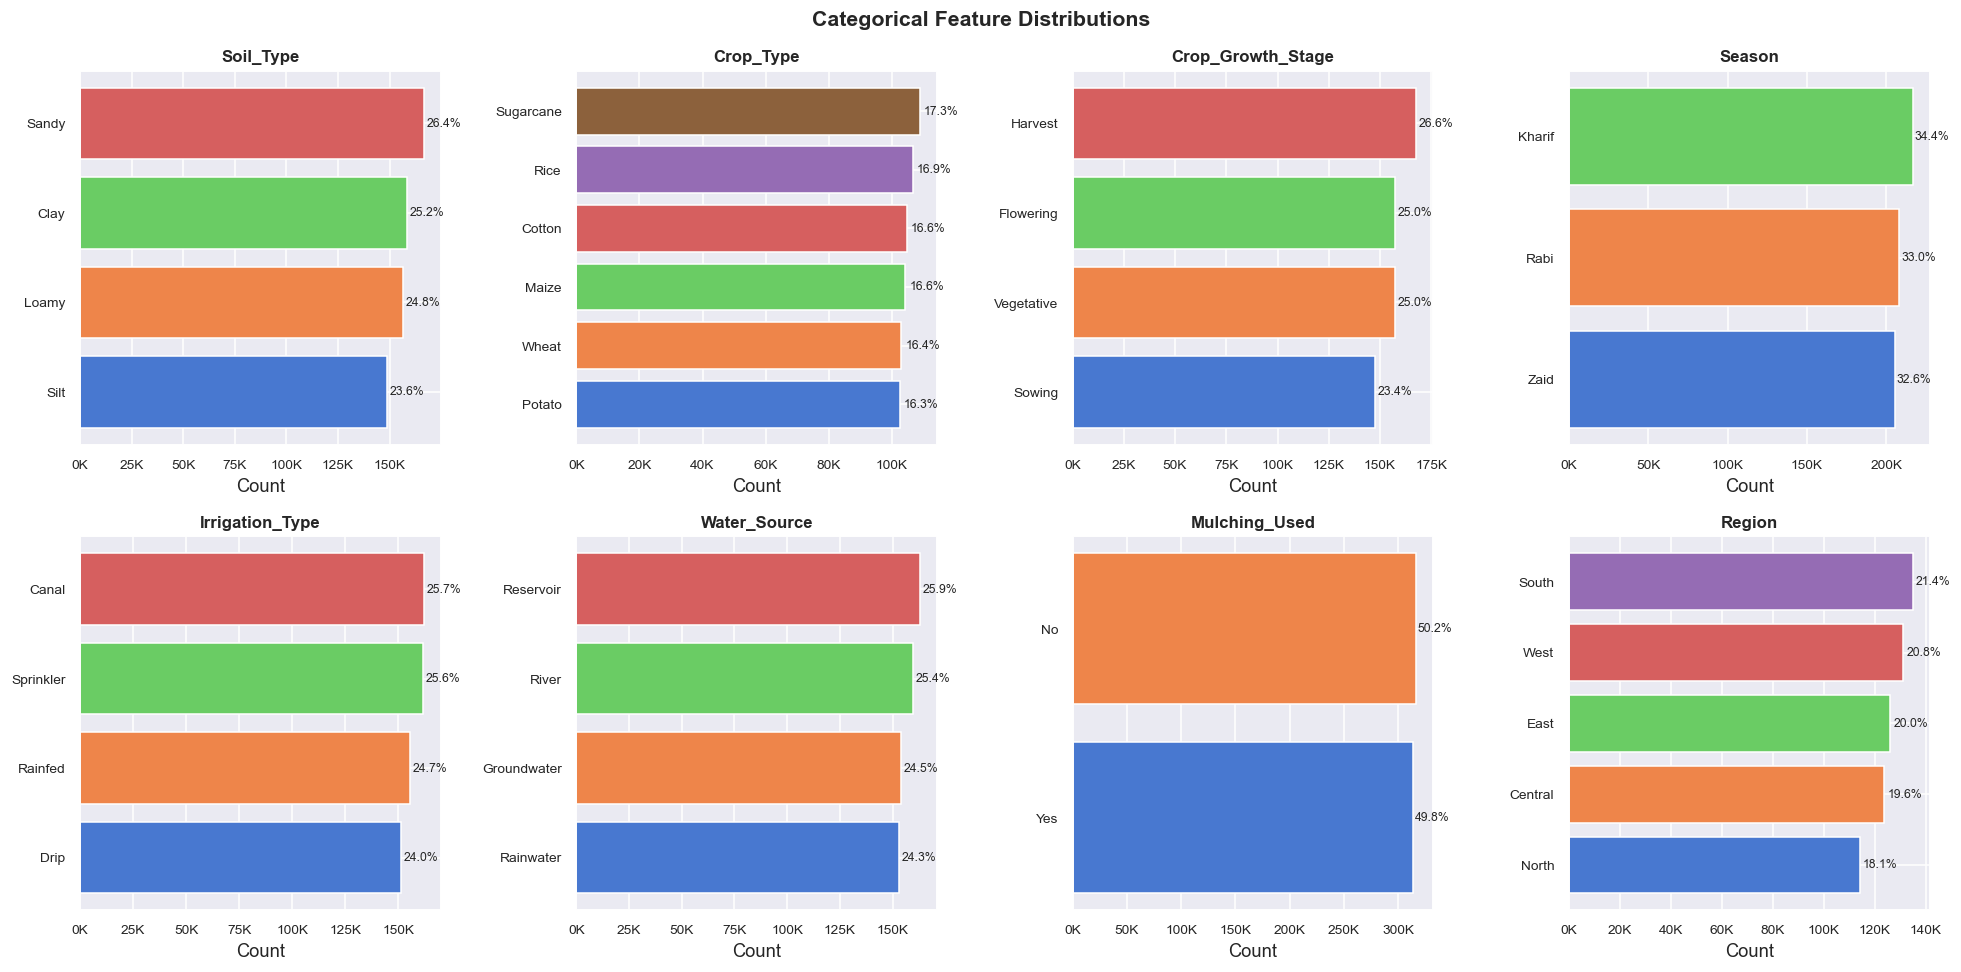

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    vc = df[col].value_counts()
    bars = axes[i].barh(vc.index[::-1], vc.values[::-1],
                        color=sns.color_palette("muted", len(vc)),
                        edgecolor="white")
    for bar, v in zip(bars, vc.values[::-1]):
        axes[i].text(bar.get_width() + len(df)*0.002, bar.get_y() + bar.get_height()/2,
                     f"{v/len(df)*100:.1f}%", va="center", fontsize=8)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Count")
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}K"))
    axes[i].tick_params(labelsize=9)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Correlation Matrix (Numeric Features)

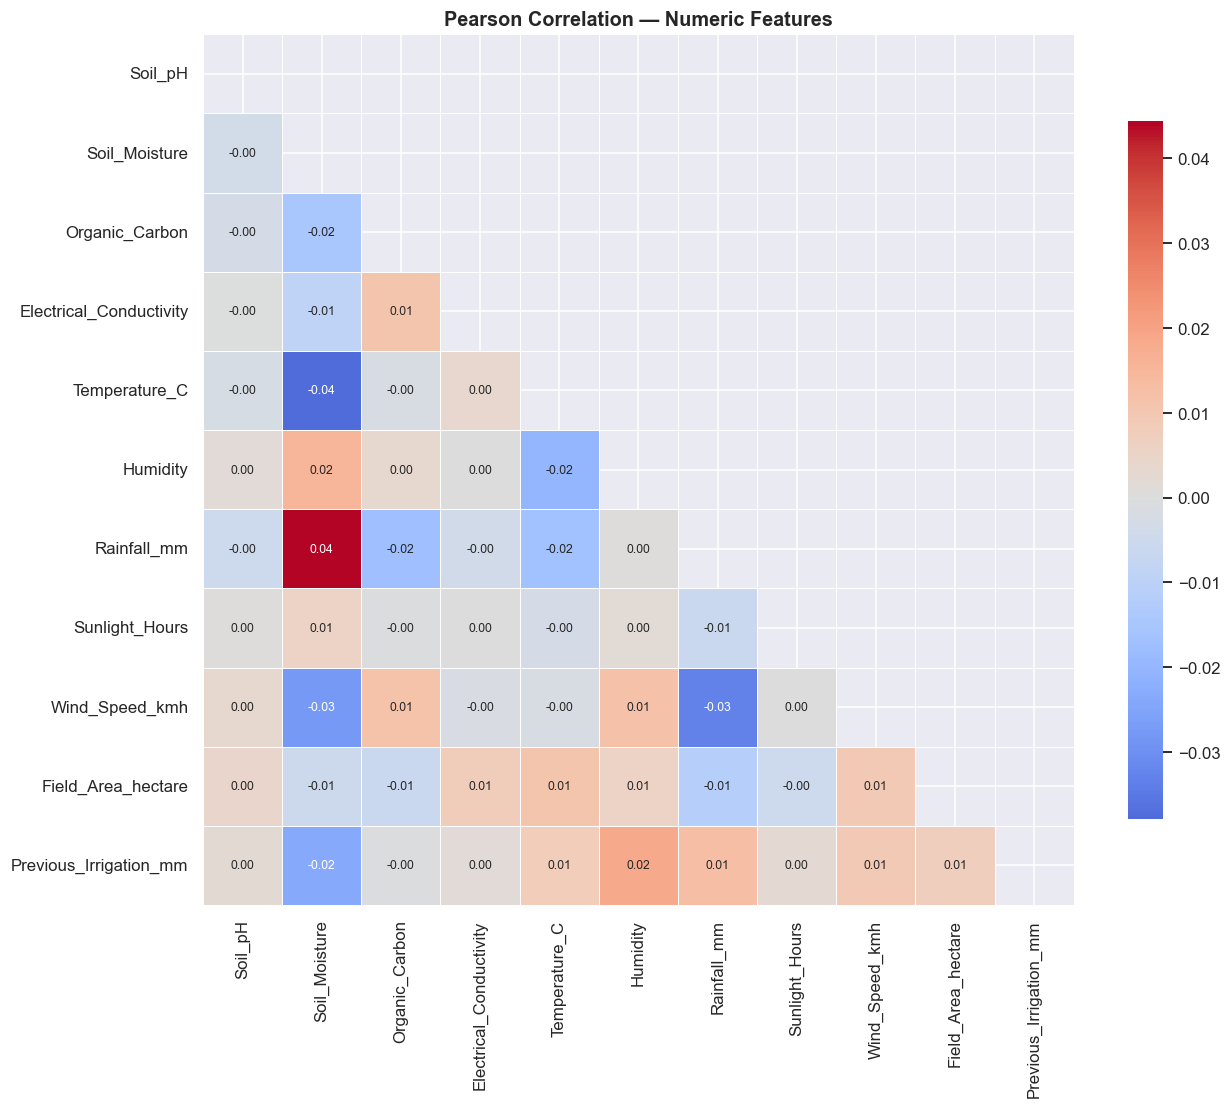

Top 10 correlated pairs:
        feat_1                 feat_2    corr
 Soil_Moisture            Rainfall_mm  0.0445
 Soil_Moisture          Temperature_C -0.0379
   Rainfall_mm         Wind_Speed_kmh -0.0328
 Soil_Moisture         Wind_Speed_kmh -0.0279
 Soil_Moisture Previous_Irrigation_mm -0.0234
 Temperature_C               Humidity -0.0204
      Humidity Previous_Irrigation_mm  0.0187
Organic_Carbon            Rainfall_mm -0.0174
 Temperature_C            Rainfall_mm -0.0168
 Soil_Moisture               Humidity  0.0154


In [9]:
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Top pairs
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append((corr.columns[i], corr.columns[j],
                      round(corr.iloc[i,j], 4)))
pairs_df = pd.DataFrame(pairs, columns=["feat_1","feat_2","corr"])
pairs_df = pairs_df.reindex(pairs_df["corr"].abs().sort_values(ascending=False).index)
print("Top 10 correlated pairs:")
print(pairs_df.head(10).to_string(index=False))


## 7. Numeric Features vs Target
> KDE plot theo từng class — thấy rõ feature nào **phân biệt tốt** giữa Low/Medium/High.


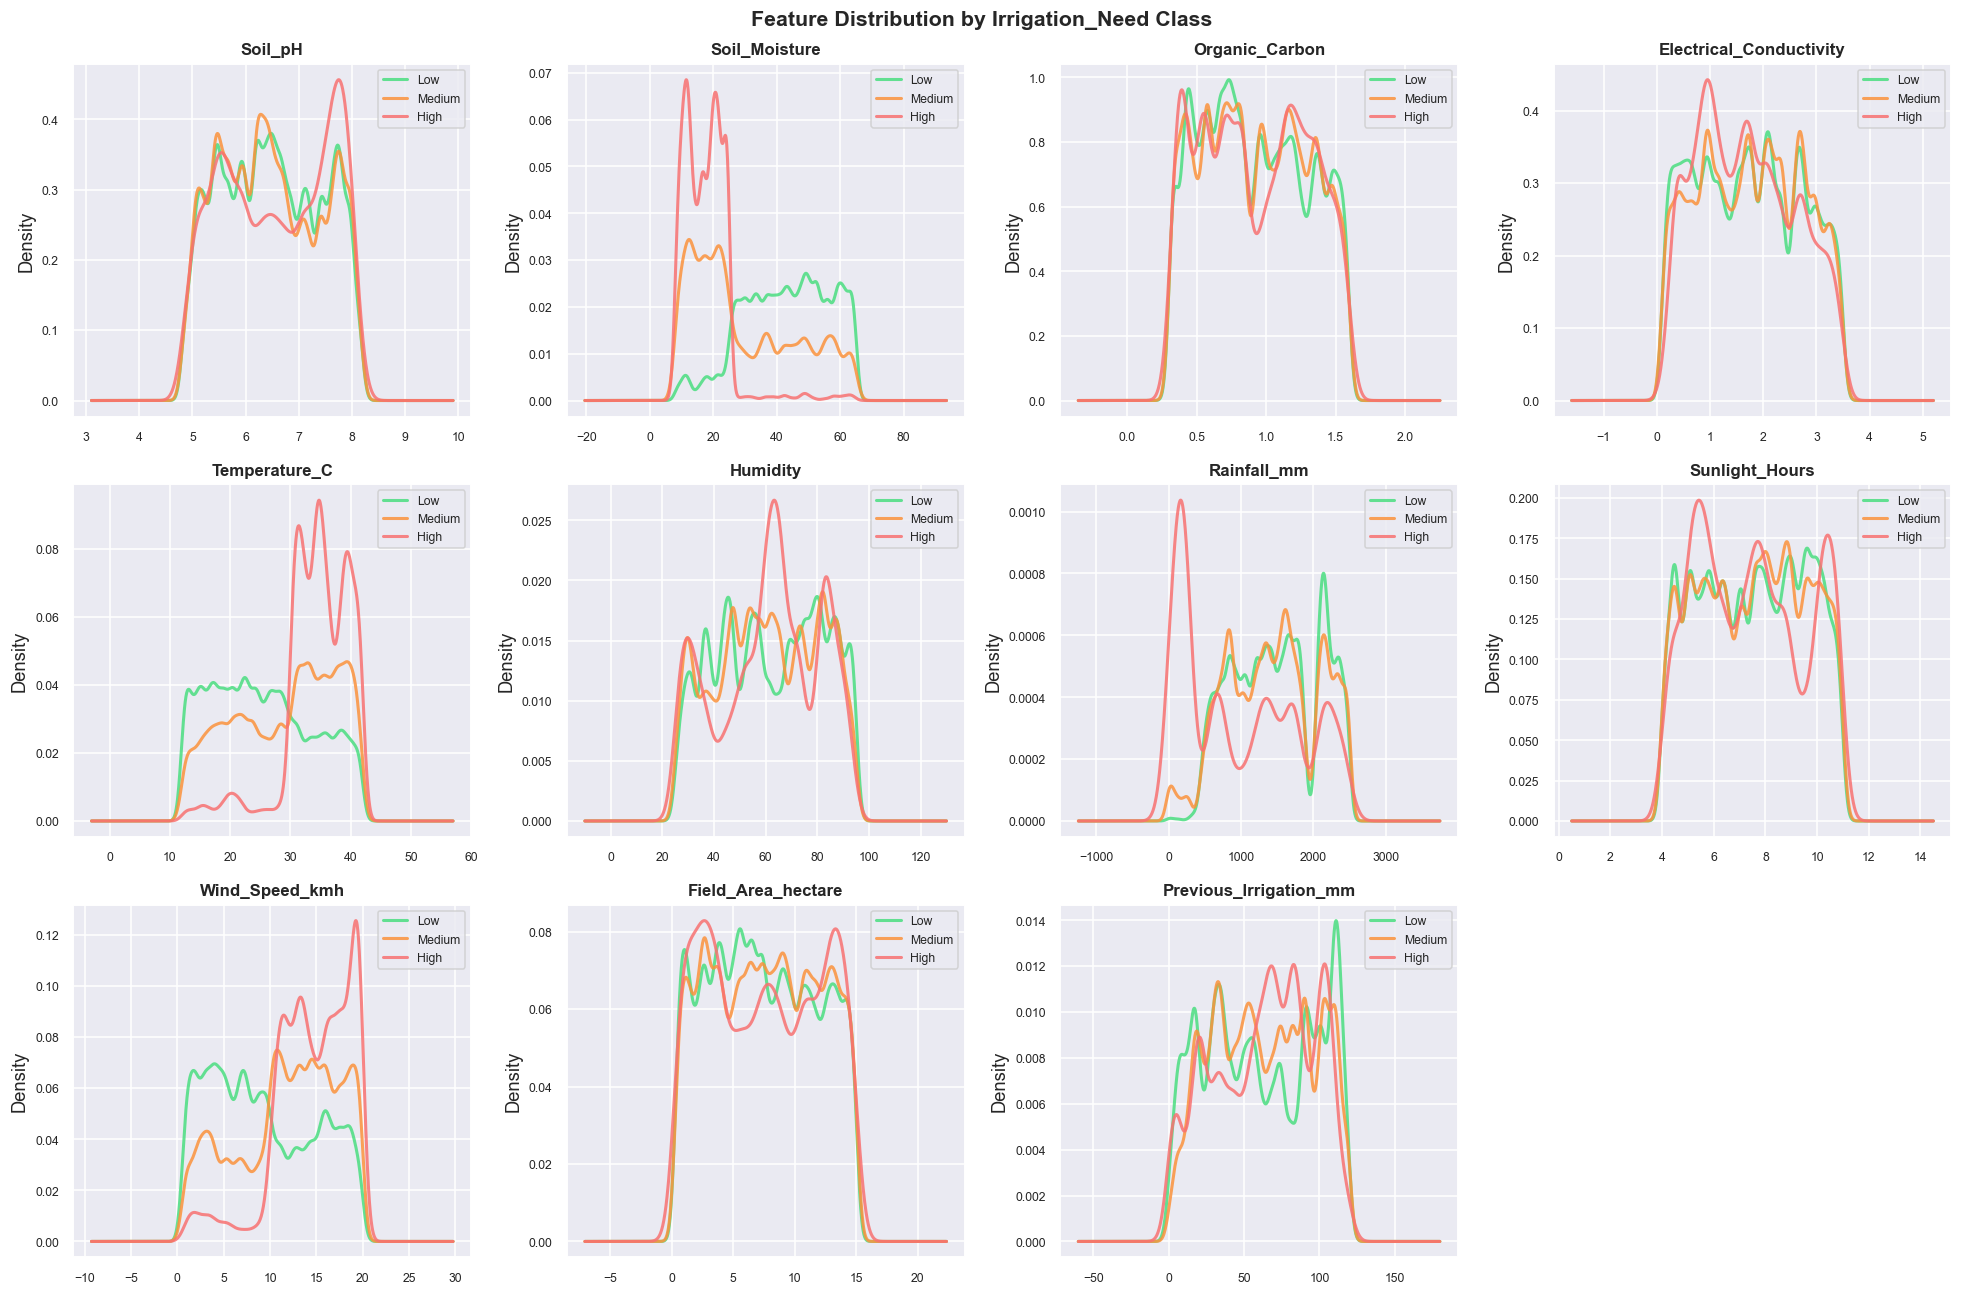

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    for cls in TARGET_ORDER:
        subset = df[df[TARGET] == cls][col]
        subset.plot.kde(ax=axes[i], label=cls,
                       color=PALETTE[cls], linewidth=2, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

# Hide unused
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distribution by Irrigation_Need Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


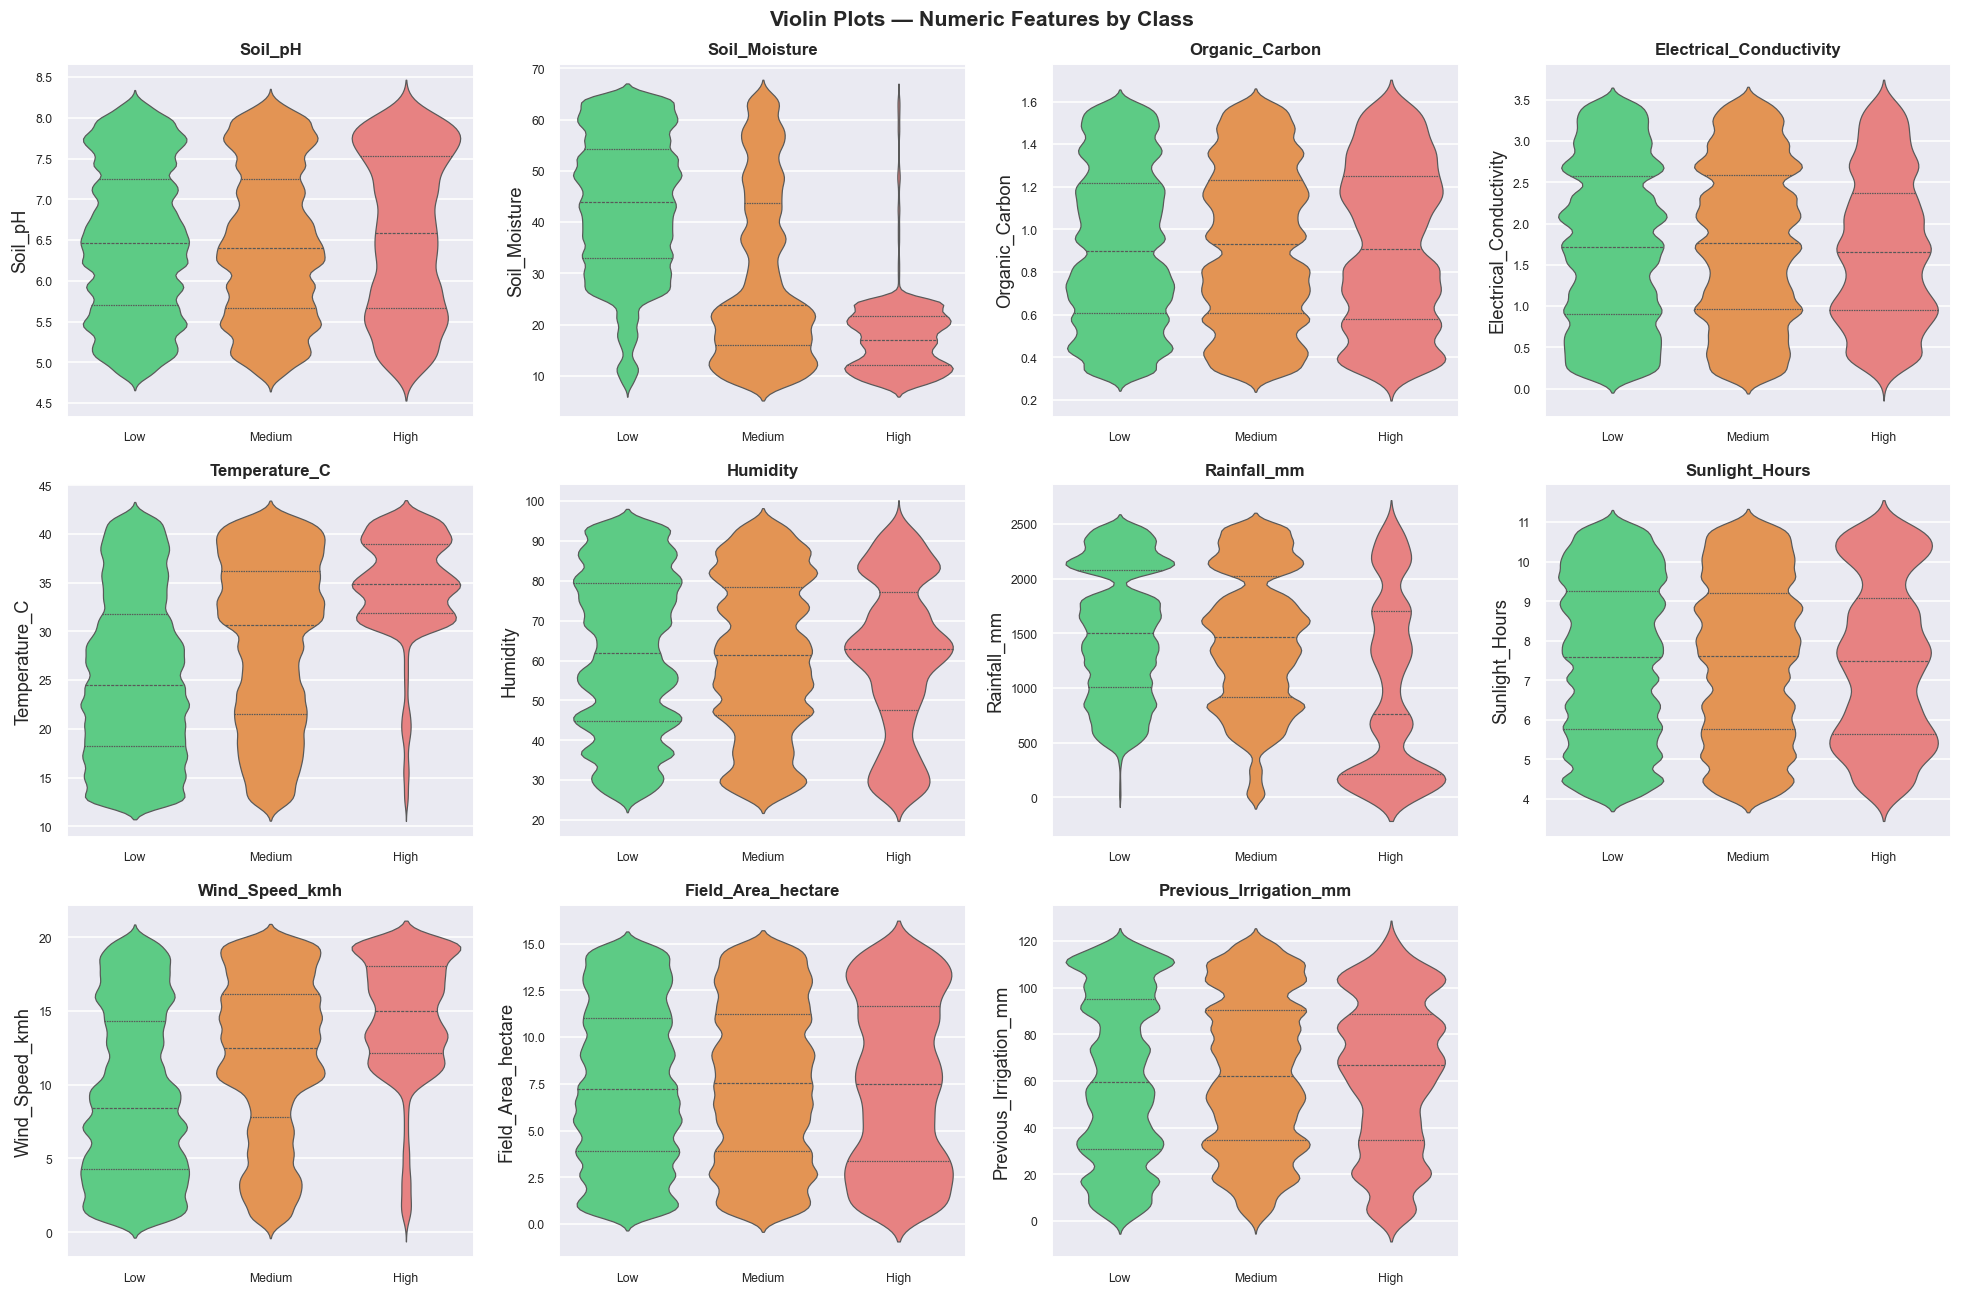

In [11]:
# ── Violin plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.violinplot(data=df, x=TARGET, y=col, order=TARGET_ORDER,
                   palette=PALETTE, ax=axes[i],
                   inner="quartile", linewidth=0.8)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Violin Plots — Numeric Features by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


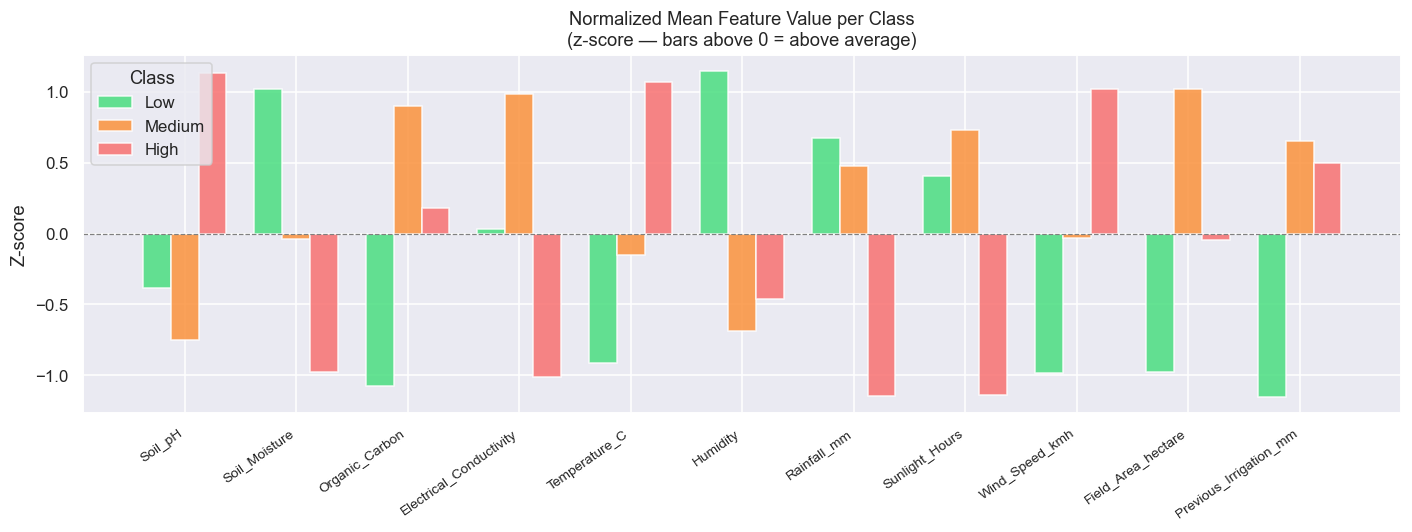

In [12]:
# ── Mean feature value per class (normalized) ─────────────────────────────────
means = df.groupby(TARGET)[NUM_COLS].mean()
means_norm = (means - means.mean()) / means.std()  # z-score per feature

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(NUM_COLS))
width = 0.25

for j, cls in enumerate(TARGET_ORDER):
    bars = ax.bar(x + j*width, means_norm.loc[cls], width,
                  label=cls, color=PALETTE[cls], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(NUM_COLS, rotation=35, ha="right", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Normalized Mean Feature Value per Class\n(z-score — bars above 0 = above average)", fontsize=12)
ax.legend(title="Class")
ax.set_ylabel("Z-score")
plt.tight_layout()
plt.show()


## 8. Categorical Features vs Target
> Stacked bar cho thấy **tỷ lệ phân phối class** trong từng category.  
> Cột nào có tỷ lệ High khác nhau rõ rệt → feature có predictive power.


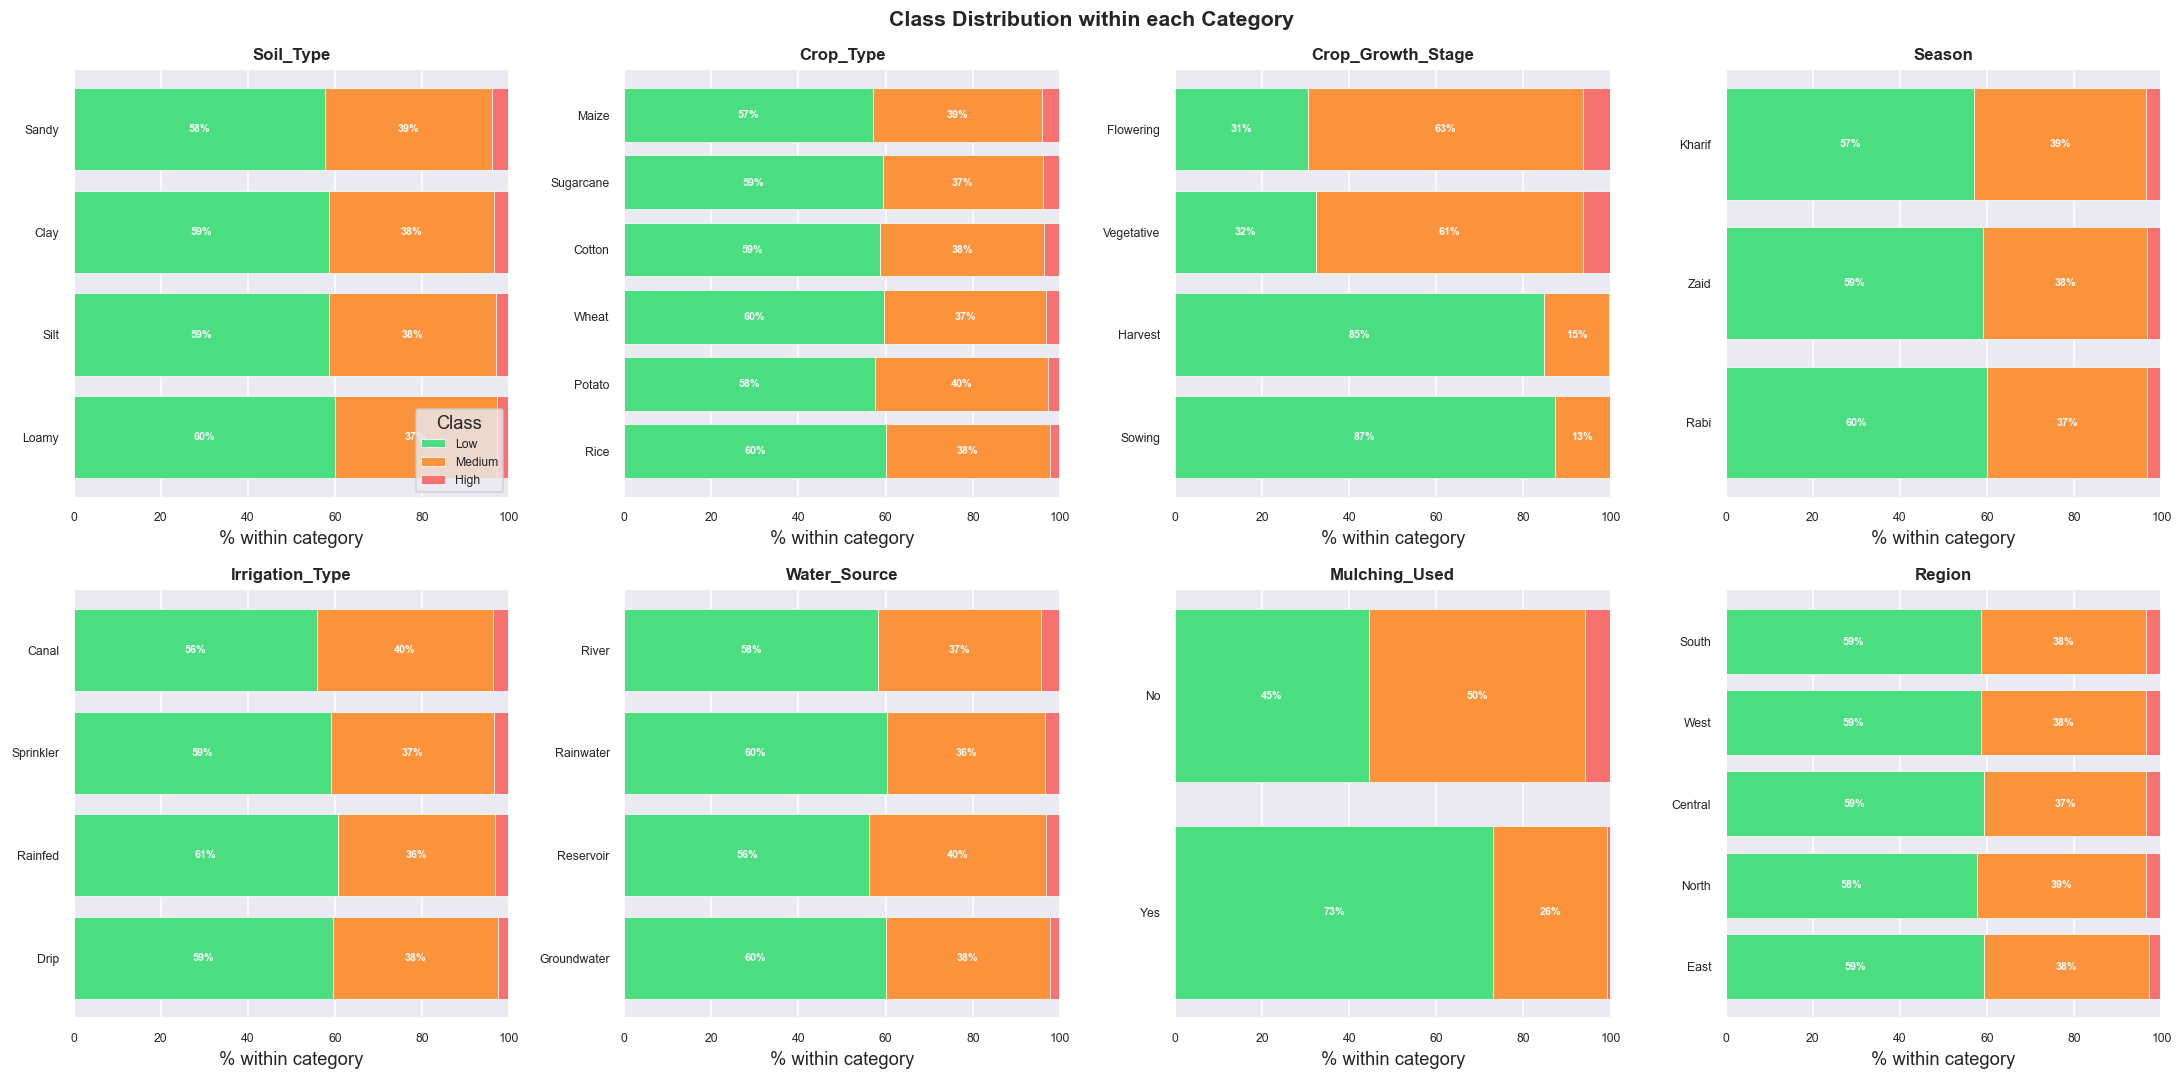

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")[TARGET_ORDER] * 100
    ct = ct.sort_values("High", ascending=True)

    bottom = np.zeros(len(ct))
    for cls in TARGET_ORDER:
        bars = axes[i].barh(ct.index, ct[cls], left=bottom,
                            color=PALETTE[cls], label=cls,
                            edgecolor="white", linewidth=0.5)
        for j, (bar, val) in enumerate(zip(bars, ct[cls])):
            if val > 8:
                axes[i].text(bottom[j] + val / 2,
                             bar.get_y() + bar.get_height() / 2,
                             f"{val:.0f}%", ha="center", va="center",
                             fontsize=7, color="white", fontweight="bold")
        bottom += ct[cls].values

    axes[i].set_xlim(0, 100)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("% within category")
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(loc="lower right", fontsize=8, title="Class")

plt.suptitle("Class Distribution within each Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

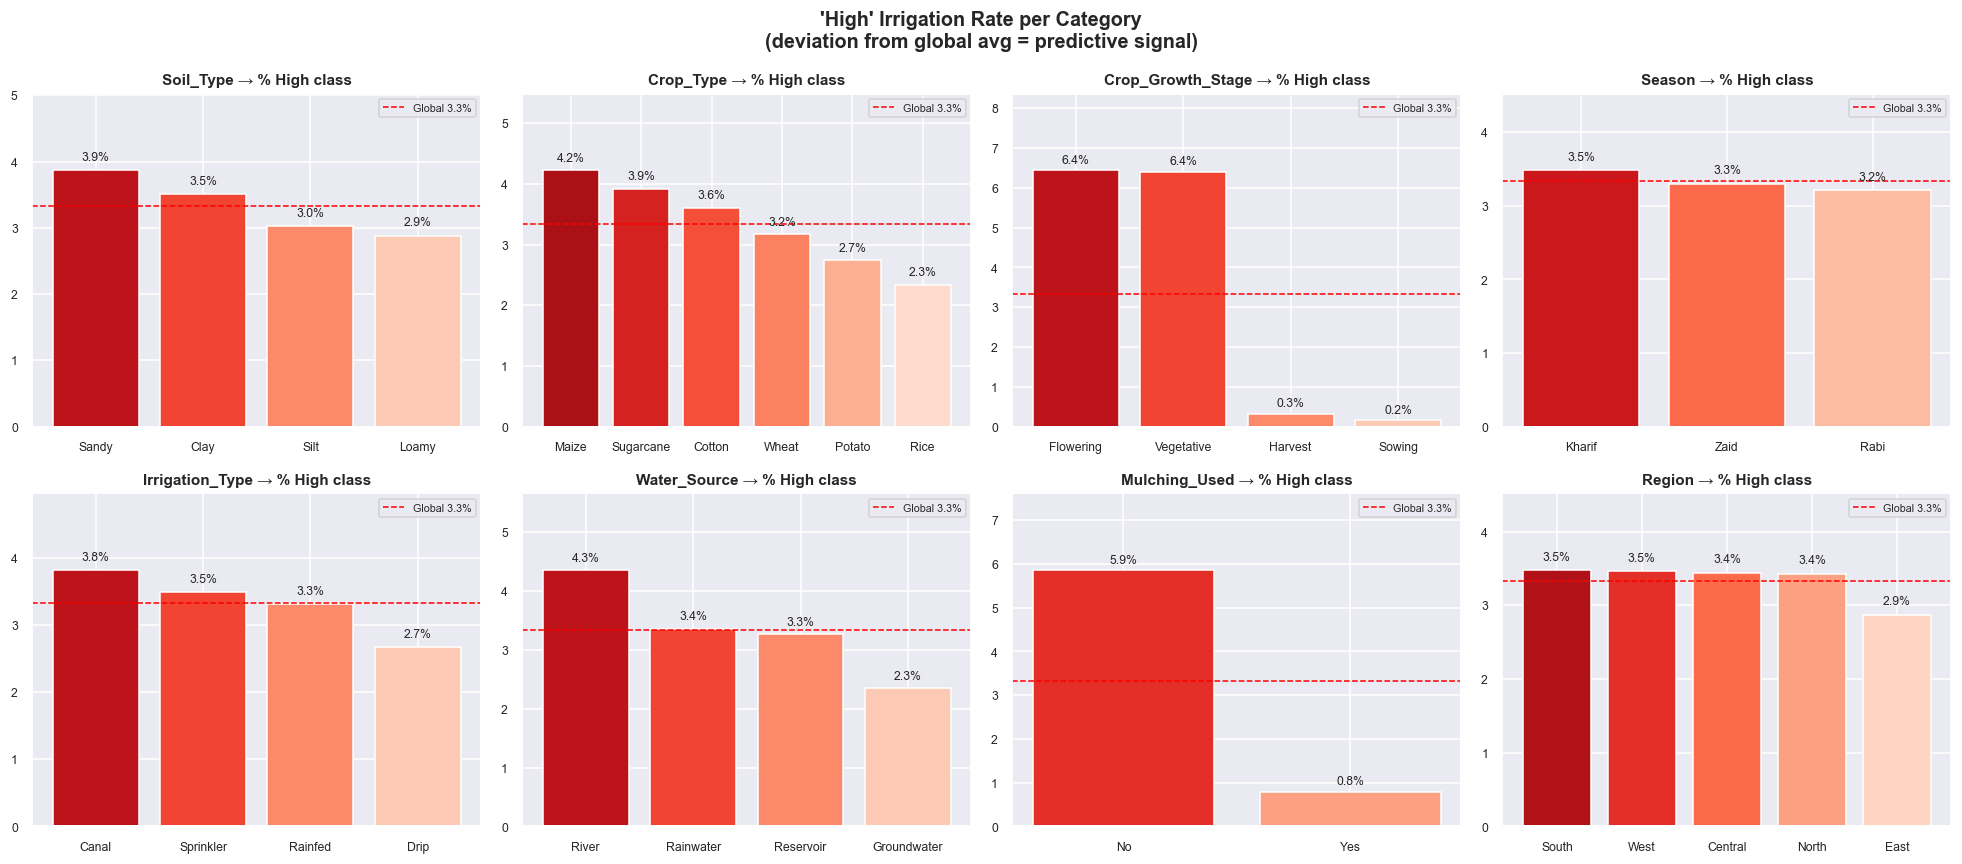

In [15]:
# ── High-class rate per category (feature discrimination power) ───────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")[TARGET_ORDER] * 100
    ct = ct.sort_values("High", ascending=False)

    bars = axes[i].bar(ct.index, ct["High"],
                       color=sns.color_palette("Reds_r", len(ct)),
                       edgecolor="white")
    for bar, v in zip(bars, ct["High"]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

    global_high = (df[TARGET] == "High").mean() * 100
    axes[i].axhline(global_high, color="red", linestyle="--",
                    linewidth=1, label=f"Global {global_high:.1f}%")
    axes[i].set_title(f"{col} → % High class", fontsize=10, fontweight="bold")
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)
    axes[i].set_ylim(0, ct["High"].max() * 1.3)

plt.suptitle("'High' Irrigation Rate per Category\n(deviation from global avg = predictive signal)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Key Insights

### 🎯 Target
- Dataset **rất mất cân bằng**: Low 58.7% · Medium 38.0% · **High chỉ 3.3%**
- Balanced Accuracy penalize nặng nếu model bỏ qua class High → cần chú ý class weighting hoặc oversampling

### 📊 Numeric Features
- **Không có missing values** — không cần imputation
- Kiểm tra kỹ boxplot để xác nhận features nào phân biệt tốt 3 class
- `Rainfall_mm`, `Soil_Moisture`, `Humidity` thường có ảnh hưởng lớn đến nhu cầu tưới

### 🏷️ Categorical Features
- Tất cả categorical có cardinality thấp (≤ 6 values) → Label Encoding / OHE đều ổn
- `Irrigation_Type` và `Crop_Type` có thể có predictive power mạnh (domain knowledge)
- `Mulching_Used` binary → đơn giản

### 💡 Gợi ý Feature Engineering
- **Interaction:** `Rainfall_mm × Soil_Moisture`, `Temperature × Humidity`
- **Ratio:** `Rainfall_mm / Previous_Irrigation_mm` (rainfall đủ thì không cần tưới)
- **GroupBy:** mean Soil_Moisture theo Crop_Type × Season
- **Flag:** `is_dry = (Rainfall_mm < threshold) & (Soil_Moisture < threshold)`

### ⚙️ Modeling Strategy
- Class imbalance → set `class_weight` trong model hoặc dùng `scale_pos_weight`
- LightGBM: `is_unbalance=True` hoặc `class_weight='balanced'`
- Monitor recall của class **High** riêng trong quá trình training
